#Наивный Байесовский классификатор

Можно построить модель классификатора, которая будет напрямую оценивать вероятность принадлежности объекта к интересующему нас классу просто на основе информации о распределении объектов по классам в обучающей выборке.

Продемонстрируем идею этого подхода на задаче классификаци вин (датасет [wine](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) из sklearn)

In [1]:
import sklearn
from sklearn.datasets import load_wine

# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html#sklearn.datasets.load_wine

# Download dataset
features, class_labels = load_wine(
    return_X_y=True, as_frame=True
)  # also we can get data in Bunch (dictionary) or pandas DataFrame

wine_dataset = features
wine_dataset["target"] = class_labels

wine_dataset.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Пример на табличных данных

Возьмём первый признак `alcohol`. По имеющийся таблице с данными легко построить функцию распределения $f(x)$, которая будет задавать вероятность $p(\text{alcohol} = x)$, и найти среди наших данных бутылку вина с параметром `alcohol`, равным $x$ (рисунок слева).

Т.к. у нас три класса, мы можем построить распределение объектов в обучающей выборке по признаку `alcohol` отдельно для каждого из этих трёх классов. Эти распределения зададут нам условную вероятность $p(\text{alcohol} = x |\text{target} = i)$ того, что объект имеет значение признака `alcohol`, равное $x$, при условии, что он относится к одному из классов с номером $i$ (рисунок справа).

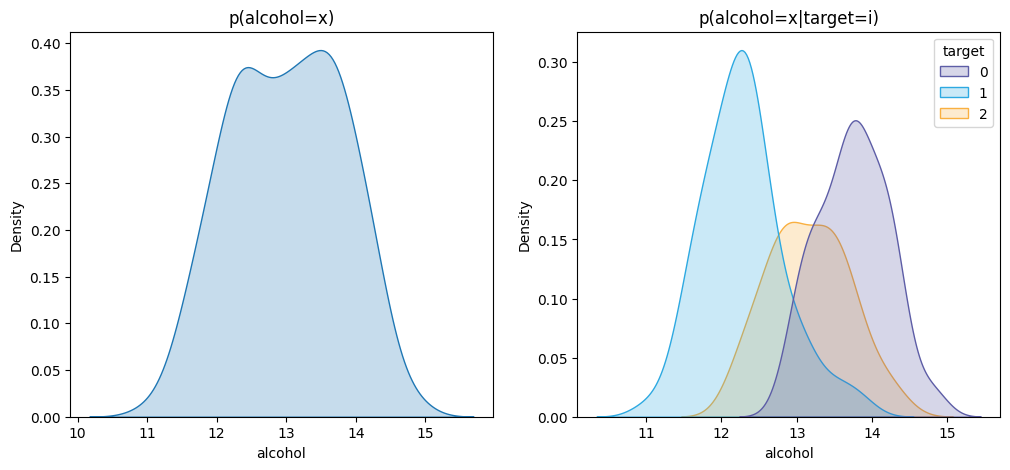

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(wine_dataset, x="alcohol", fill=True, ax=axes[0])
axes[0].set_title("p(alcohol=x)")

sns.kdeplot(
    wine_dataset,
    x="alcohol",
    hue="target",
    palette=sns.color_palette(["#5D5DA6", "#2DA9E1", "#F9B041"]),
    fill=True,
    ax=axes[1],
)
axes[1].set_title("p(alcohol=x|target=i)")
plt.show()

Посмотрев на плотности распределений по классам (рисунок справа), мы можем предположить, что бутылка с значением $\text{alcohol} = 11.3$ будет относиться к 1 классу.

На языке формул наш “метод пристального вглядывания” можно записать с помощью формулы для условной вероятности по [теореме Байеса 📚[wiki]](https://en.wikipedia.org/wiki/Bayes'_theorem):

$$\large p(\text{target} = i | \text{alcohol} = x) = \frac{p(\text{alcohol} = x | \text{target} = i )p(\text{target} = i )}{p(\text{alcohol} = x)},$$

где $p(\text{target} = i)$ — доля объектов класса $i$ в датасете, а $p(\text{target} = i | \text{alcohol} = X)$ — вероятность того, что объект принадлежит классу $i$, при условии того, что признак `alcohol` у него принимает значение $X$.


Мы поняли, откуда в названии метода **Байес**, теперь разберемся, **почему он “наивный”**.

Мы использовали только один признак: `alcohol`. Всего же у нас 13 признаков.

$$\large p(\text{target} = i |\text{features} = \vec x ) = \frac{p(\text{features} = \vec x | \text{target} = i )p(\text{target} = i )}{p(\text{features} = \vec x)}$$

**“Наивность”** Байеса состоит в том, что эта модель будет рассматривать признаки как **независимые случайные величины**:
$$\large p(\text{features} = \vec x)=p(\text{feature}_1 = x_1)\cdotp(\text{feature}_2 = x_2)...(\text{feature}_n = x_n)$$

Если мы решаем задачу классификации на $k$ классов, то для объекта с набором признаком $\vec x$ по формуле выше мы получим $k$ чисел, характеризующих вероятность принадлежности данного объекта к различным классам. Для финального принятия решения нам останется выбрать тот класс, для которого вероятность принадлежности наивысшая:

$$\large \text{prediction} = \underset{i}{\text{argmax}}{\left(p(\text{target} = i |\text{features} = \vec x )\right)}.$$

Вернёмся к нашему датасету Wine и попробуем решить задачу классификации для него при помощи предложенного алгоритма.

Как обычно, разделим наш датасет на тренировочную и валидационную выборки:

In [3]:
from sklearn.model_selection import train_test_split

# Split the data into train and test data
x_train, x_test, y_train, y_test = train_test_split(
    features.values, class_labels.values, test_size=0.25, random_state=42
)

Возьмём реализацию Наивного Байесовского классификатора `GaussianNB` из [библиотеки Sklearn 🛠️[doc]](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html#sklearn.naive_bayes.GaussianNB). `GaussianNB` **использует оценку распределения признаков с помощью** [Гауссового распределения](https://ru.wikipedia.org/wiki/%D0%9D%D0%BE%D1%80%D0%BC%D0%B0%D0%BB%D1%8C%D0%BD%D0%BE%D0%B5_%D1%80%D0%B0%D1%81%D0%BF%D1%80%D0%B5%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D0%B5).  Обучим её на тренировочном датасете и измерим качество на отложенной валидационной выборке:

In [4]:
from sklearn.metrics import f1_score
from sklearn.naive_bayes import GaussianNB

# Train the model
model = GaussianNB()
model.fit(x_train, y_train)

# Calculate F1_score
pred = model.predict(x_test)
f1_score(y_test, pred, average="macro")

1.0

Благодаря простоте модельного датасета Wine наша наивная статистическая модель показала отличное качество работы. Это связано с “простотой” датасета — признаки классов имеют унимодальные распределения (один пик на плотности распределения), для более сложных данных (многомодальные распределения) такого не будет.

Тем не менее, подход к решению задачи классификации, связанный с построением модели предсказания принадлежности объекта к имеющимся классам, оказался конструктивным.

С идеей применения наивного Байесовского классификатора в NLP задаче можно познакомиться в отдельном блокноте [[colab] 🥨 Naive Bayes NLP](https://colab.research.google.com/drive/1JUMs9TBWxlCTsqw2T-y3oxMe2WZxLYtJ).


# Наивный Байесовский классификатор в NLP задаче

Наивный Байесовский классификатор часто используют в задаче обнаружения спама, и пример его использования в такой задаче может показаться ещё более наглядным.

В рамках данной задачи у нас имеются:
- Датасет из текстов сообщений с некоторым фиксированным словарём возможных слов.
- Два класса сообщений: спам и нормальное.
- Признаковое описание для каждого сообщения, характеризующее количество вхождений каждого из слов словаря в текст сообщения.

На основе этой информации нам нужно научиться отделять нормальные письма от спама. Все письма состоят из 4-х слов: **‘Добрый’, ‘День’, ‘Гости’, ‘Деньги’**. При этом мы уже посчитали, сколько раз каждое слово встречается в каждом классе.

Мы можем посчитать вероятность встретить слово **‘Добрый’** в нормальном письме: берем количество слов **‘Добрый’** и делим на количество слов во всех нормальных письмах (с повторениями). Аналогично для других слов.

<center><img src="https://edunet.kea.su/repo/EduNet-additions/L02/naive_bayes_1.png" width="900"/></center>

Делаем то же самое для слов из спама.

<center><img src="https://edunet.kea.su/repo/EduNet-additions/L02/naive_bayes_2.png" width="900"/></center>

Считаем вероятность того, что письмо было нормальным. Для этого количество нормальных писем делим на общее количество писем. Аналогично для спама. Это $p(\text{target} = i)$.

<center><img src="https://edunet.kea.su/repo/EduNet-additions/L02/naive_bayes_3.png" width="900"/></center>

Чтобы получить вероятность нормального письма с фразой **‘Добрый День’** в "наивном" предположении, мы можем перемножить вероятности нормального письма со словом **‘Добрый’** и нормального письма со словом **‘День’**. Это произведение будет $p(\text{target} = i | \text{Features} = \vec X)$.

Считаем $p(\text{Features} = \vec X|\text{target} = i) p(\text{target} = i)$:

<center><img src="https://edunet.kea.su/repo/EduNet-additions/L02/naive_bayes_3_5.png" width="900"/></center>

[[doc] 🛠️ Пример кода](https://scikit-learn.org/stable/auto_examples/text/plot_document_classification_20newsgroups.html#benchmarking-classifiers)

Если вы работаете с NLP, советуем ознакомиться с Latent Dirichlet Allocation:
* [[video] 📺 Latent Dirichlet Allocation (Part 1 of 2)](https://www.youtube.com/watch?v=T05t-SqKArY),
* [[video] 📺 Training Latent Dirichlet Allocation: Gibbs Sampling (Part 2 of 2)](https://www.youtube.com/watch?v=BaM1uiCpj_E).